In [54]:
import numpy as np

# ── Pretrained checkpoint ─────────────────────────────────────────────────────
CORRELATION         = 0.00
PRETRAIN_CHECKPOINT = f"pretrain_corr_{CORRELATION:.2f}.pth"

# ── Concentration sweep ───────────────────────────────────────────────────────
CONCENTRATIONS = [0.2, 0.3, 0.4, 0.6, 0.8, 0.9]#np.linspace(0.1, 0.9, 5).tolist()   # 10 values from 0.05 → 0.95

# ── Finetuning hyperparameters ────────────────────────────────────────────────
FINETUNE_STEPS        = 5_000
FINETUNE_BATCH_SIZE   = 96
FINETUNE_LR           = 1e-5
FINETUNE_MIN_LR       = 1e-7
FINETUNE_WARMUP_RATIO = 0.2
MAX_GRAD_NORM         = 1.0

# ── Reverse training hyperparameters ──────────────────────────────────────────
REVERSE_STEPS        = 2_500
REVERSE_BATCH_SIZE   = 96
REVERSE_LR           = 1e-5
REVERSE_MIN_LR       = 1e-7
REVERSE_WARMUP_RATIO = 0.2

# ── Logging & evaluation ──────────────────────────────────────────────────────
LOG_INTERVAL          = 200     # keep this reasonable given the sweep cost
METRICS               = ["loss", "answer_acc"]

# ── Gradient / drift probing ──────────────────────────────────────────────────
GRAD_PROBE_BATCH_SIZE = 32

# ── Tasks ─────────────────────────────────────────────────────────────────────
FINETUNE_TASK_NAMES = [
    "count_a",
    "count_b", "count_c",
    "count_aa", "count_bb", "count_cc",
    "index_a",  "index_b",  "index_c",
    "index_aa", "index_bb", "index_cc",
    "token_at_40",
]
PRETRAIN_TASK_NAMES = [
    "count_b", "count_c",
    "count_aa", "count_bb", "count_cc",
    "index_a",  "index_b",  "index_c",
    "index_aa", "index_bb", "index_cc",
    "token_at_40",
]
SPECIAL_TASK = "count_a"

# ── Eval dataset sizes ────────────────────────────────────────────────────────
VAL_EXAMPLES        = 500
EVAL_PER_OTHER_TASK = 500

# ── Model architecture (must match checkpoint) ────────────────────────────────
MODEL_CFG = dict(
    block_size=512, n_layer=6, n_head=6, n_embd=192,
    embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1,
)

# ── PCFG pools ────────────────────────────────────────────────────────────────
POOL_N_CORRELATED   = 0#10_000
POOL_N_UNCORRELATED = 100_000
CHUNK_SIZE          = 250

# ── Optimizer ─────────────────────────────────────────────────────────────────
OPTIMIZER_CFG = dict(type="AdamW", weight_decay=0.0, betas=[0.9, 0.95], eps=1e-8)

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED   = 42
DEVICE = "auto"

In [55]:
CONCENTRATIONS

[0.2, 0.3, 0.4, 0.6, 0.8, 0.9]

In [56]:
import os, math, random, itertools
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm

from config       import CFG
from config_utils import (
    build_optimizer, build_task_registry,
    get_device, get_warmup_steps, set_seed,
)
from mingpt   import GPT, GPTConfig
from pcfg_gen import (
    CharTokenizer, PCFGDataset, PCFGGenerator,
    generate_dataset, build_pools,
)
from train_help import (
    sample_batch, get_cosine_lr,
    _build_val_loaders, _evaluate_loader,
    calculate_answer_accuracy,
)

set_seed(SEED)
device = get_device(DEVICE)
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")
print(f"\nConcentrations to sweep ({len(CONCENTRATIONS)}):")
for c in CONCENTRATIONS:
    print(f"  {c:.3f}")

Device : cuda
PyTorch: 2.10.0+cu130

Concentrations to sweep (6):
  0.200
  0.300
  0.400
  0.600
  0.800
  0.900


In [57]:
pcfg = PCFGGenerator()

pools = build_pools(
    pcfg_gen       = pcfg,
    n_correlated   = POOL_N_CORRELATED,
    n_uncorrelated = POOL_N_UNCORRELATED,
    chunk_size     = CHUNK_SIZE,
    verbose        = True,
)
print(f"\nPool sizes — correlated: {len(pools['correlated']):,} | "
      f"uncorrelated: {len(pools['uncorrelated']):,}")

Building PCFG pools: 0 correlated + 100,000 uncorrelated strings …
Pools ready — 0 correlated, 100,000 uncorrelated from 0 total generations (0.0% acceptance rate).

Pool sizes — correlated: 0 | uncorrelated: 100,000


In [58]:
tokenizer     = CharTokenizer()
task_registry = build_task_registry(CFG["task_definitions"])

ALL_TASKS   = CFG["task_sets"]["all"]
OTHER_TASKS = [t for t in ALL_TASKS if t not in ("count_a", "count_b")]

MAX_LEN          = CFG["tokenizer"]["max_length"]
MASK_ANSWER_ONLY = CFG["tokenizer"]["mask_answer_only_val"]

print("Generating count_a eval set …")
count_a_examples = generate_dataset(
    n_examples=VAL_EXAMPLES, task_names=["count_a"],
    pcfg_gen=pcfg, task_reg=task_registry, chunk_size=CHUNK_SIZE,
)
print("Generating count_b eval set …")
count_b_examples = generate_dataset(
    n_examples=VAL_EXAMPLES, task_names=["count_b"],
    pcfg_gen=pcfg, task_reg=task_registry, chunk_size=CHUNK_SIZE,
)
print(f"Generating other-task eval sets ({len(OTHER_TASKS)} tasks × {EVAL_PER_OTHER_TASK}) …")
other_examples = []
for t in OTHER_TASKS:
    other_examples += generate_dataset(
        n_examples=EVAL_PER_OTHER_TASK, task_names=[t],
        pcfg_gen=pcfg, task_reg=task_registry, chunk_size=CHUNK_SIZE,
    )

eval_datasets = {
    "count_a":       PCFGDataset(count_a_examples, tokenizer,
                                 max_length=MAX_LEN, mask_answer_only=MASK_ANSWER_ONLY),
    "count_b":       PCFGDataset(count_b_examples, tokenizer,
                                 max_length=MAX_LEN, mask_answer_only=MASK_ANSWER_ONLY),
    "all_other_avg": PCFGDataset(other_examples,   tokenizer,
                                 max_length=MAX_LEN, mask_answer_only=MASK_ANSWER_ONLY),
}
print("\nEval dataset sizes:")
for name, ds in eval_datasets.items():
    print(f"  {name:<18} {len(ds):>6}")

Tokenizer vocabulary size: 267
Generating count_a eval set …
Generating count_b eval set …
Generating other-task eval sets (11 tasks × 500) …

Eval dataset sizes:
  count_a               500
  count_b               500
  all_other_avg        5500


In [59]:
gpt_config = GPTConfig(
    vocab_size  = tokenizer.vocab_size,
    block_size  = MODEL_CFG["block_size"],
    n_layer     = MODEL_CFG["n_layer"],
    n_head      = MODEL_CFG["n_head"],
    n_embd      = MODEL_CFG["n_embd"],
    embd_pdrop  = MODEL_CFG["embd_pdrop"],
    resid_pdrop = MODEL_CFG["resid_pdrop"],
    attn_pdrop  = MODEL_CFG["attn_pdrop"],
)

# Detect layer prefixes once from a temporary model instance
_tmp = GPT(gpt_config)
layer_prefixes = sorted({
    ".".join(n.split(".")[:3])
    for n, _ in _tmp.named_parameters()
    if n.startswith("transformer.h.")
})
del _tmp
layer_labels = [f"L{i}" for i in range(len(layer_prefixes))]
n_layers     = len(layer_prefixes)
print(f"Transformer block layers ({n_layers}): {layer_prefixes}")


def get_layer_grads(model, batch):
    """One forward+backward; returns {layer_prefix: flat grad vector}. No opt step."""
    model.train()
    model.zero_grad()
    _, loss = model(batch["input_ids"].to(device), batch["target_ids"].to(device))
    loss.backward()
    grads = {}
    for prefix in layer_prefixes:
        vecs = [p.grad.detach().cpu().float().flatten()
                for n, p in model.named_parameters()
                if n.startswith(prefix) and p.grad is not None]
        if vecs:
            grads[prefix] = torch.cat(vecs)
    model.zero_grad()
    return grads


def cossim(a, b):
    return (a @ b / (a.norm() * b.norm()).clamp(min=1e-12)).item()


def probe_batch(task_name):
    return sample_batch(
        batch_size=GRAD_PROBE_BATCH_SIZE, task_names=[task_name],
        task_weights=[1.0], pcfg_gen=pcfg, task_reg=task_registry,
        tokenizer=tokenizer, chunk_size=CHUNK_SIZE, mask_answer_only=False,
        data_pools=pools, correlation=CORRELATION,
    )


def compute_grad_and_drift_metrics(model, base_params):
    other_tasks   = [t for t in FINETUNE_TASK_NAMES if t != SPECIAL_TASK]
    special_grads = get_layer_grads(model, probe_batch(SPECIAL_TASK))
    other_grads   = {t: get_layer_grads(model, probe_batch(t)) for t in other_tasks}

    sv_o, o_o, drift = [], [], []
    for prefix in layer_prefixes:
        g_sp       = special_grads.get(prefix)
        other_vecs = [other_grads[t][prefix] for t in other_tasks
                      if prefix in other_grads[t]]

        # special vs mean-other
        if g_sp is not None and other_vecs:
            sv_o.append(cossim(g_sp, torch.stack(other_vecs).mean(0)))
        else:
            sv_o.append(float("nan"))

        # mean pairwise among others
        if len(other_vecs) >= 2:
            pairs = list(itertools.combinations(other_vecs, 2))
            o_o.append(float(np.mean([cossim(a, b) for a, b in pairs])))
        elif len(other_vecs) == 1:
            o_o.append(1.0)
        else:
            o_o.append(float("nan"))

        # weight drift
        diffs = [(p.detach().cpu().float() - base_params[n]).flatten()
                 for n, p in model.named_parameters()
                 if n.startswith(prefix) and n in base_params]
        drift.append(torch.cat(diffs).norm().item() if diffs else float("nan"))

    return sv_o, o_o, drift

number of parameters: 2.82M
Transformer block layers (6): ['transformer.h.0', 'transformer.h.1', 'transformer.h.2', 'transformer.h.3', 'transformer.h.4', 'transformer.h.5']


In [60]:
assert os.path.exists(PRETRAIN_CHECKPOINT), f"Not found: {PRETRAIN_CHECKPOINT}"

# all_histories[concentration] = history dict
all_histories = {}

for conc_idx, concentration in enumerate(CONCENTRATIONS):
    print(f"\n{'='*70}")
    print(f"  Concentration {conc_idx+1}/{len(CONCENTRATIONS)}: {concentration:.3f}")
    print(f"{'='*70}")

    # ── Fresh model from checkpoint ───────────────────────────────────────────
    model = GPT(gpt_config).to(device)
    ckpt  = torch.load(PRETRAIN_CHECKPOINT, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    # Frozen base weights for drift (will be updated at each eval step)
    last_eval_params = {
        name: param.detach().cpu().float().clone()
        for name, param in model.named_parameters()
    }

    # ── Task weights ──────────────────────────────────────────────────────────
    n_other          = len(FINETUNE_TASK_NAMES) - 1
    other_w          = (1.0 - concentration) / n_other
    finetune_weights = [concentration] + [other_w] * n_other

    # ── Optimizer ─────────────────────────────────────────────────────────────
    optimizer    = build_optimizer(model.parameters(), OPTIMIZER_CFG, FINETUNE_LR)
    warmup_steps = get_warmup_steps(FINETUNE_STEPS, warmup_ratio=FINETUNE_WARMUP_RATIO)
    val_loaders  = _build_val_loaders(eval_datasets, FINETUNE_BATCH_SIZE, tokenizer)
    metrics_set  = set(METRICS)

    # ── History ───────────────────────────────────────────────────────────────
    history = {
        "steps"                        : [],
        "train_loss"                   : [],
        "train_answer_acc"             : [],
        "val"                          : {n: {"loss": [], "answer_acc": []}
                                          for n in val_loaders},
        "grad_cossim_special_vs_other" : [],
        "grad_cossim_other_vs_other"   : [],
        "weight_drift"                 : [],
    }

    # ── Training loop ─────────────────────────────────────────────────────────
    log_prefix = f"conc={concentration:.2f}"

    for step in range(1, FINETUNE_STEPS + 1):
        cur_lr = get_cosine_lr(step, FINETUNE_STEPS, FINETUNE_LR,
                               FINETUNE_MIN_LR, warmup_steps)
        for pg in optimizer.param_groups:
            pg["lr"] = cur_lr

        batch = sample_batch(
            batch_size=FINETUNE_BATCH_SIZE, task_names=FINETUNE_TASK_NAMES,
            task_weights=finetune_weights, pcfg_gen=pcfg, task_reg=task_registry,
            tokenizer=tokenizer, chunk_size=CHUNK_SIZE, mask_answer_only=False,
            data_pools=pools, correlation=CORRELATION,
        )

        model.train()
        optimizer.zero_grad()
        logits, loss = model(batch["input_ids"].to(device),
                             batch["target_ids"].to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        train_acc, _ = calculate_answer_accuracy(
            logits, batch["target_ids"].to(device), batch["answer_positions"])

        if step % LOG_INTERVAL == 0:
            history["steps"].append(step)
            history["train_loss"].append(loss.item())
            history["train_answer_acc"].append(train_acc)

            log_parts = [f"{log_prefix} step {step}/{FINETUNE_STEPS}",
                         f"loss={loss.item():.4f}", f"acc={train_acc:.3f}",
                         f"lr={cur_lr:.2e}"]

            for name, loader in val_loaders.items():
                v_loss, v_acc = _evaluate_loader(model, loader, device, metrics_set)
                history["val"][name]["loss"].append(v_loss)
                history["val"][name]["answer_acc"].append(v_acc)
                log_parts += [f"{name}_acc={v_acc:.3f}"]

            sv_o, o_o, drift = compute_grad_and_drift_metrics(model, last_eval_params)
            history["grad_cossim_special_vs_other"].append(sv_o)
            history["grad_cossim_other_vs_other"].append(o_o)
            history["weight_drift"].append(drift)
            
            # Update last_eval_params to current model state for next eval
            last_eval_params = {
                name: param.detach().cpu().float().clone()
                for name, param in model.named_parameters()
            }

            log_parts += [
                f"grad_sim(spc↔other)={np.nanmean(sv_o):.3f}",
                f"grad_sim(o↔o)={np.nanmean(o_o):.3f}",
                f"drift={np.nanmean(drift):.4f}",
            ]
            print(" | ".join(log_parts))

    all_histories[concentration] = history
    print(f"  Done with concentration={concentration:.3f}")

print("\n\nSweep complete!")


  Concentration 1/6: 0.200
number of parameters: 2.82M
conc=0.20 step 200/5000 | loss=0.4538 | acc=0.729 | lr=2.00e-06 | count_a_acc=0.196 | count_b_acc=0.998 | all_other_avg_acc=0.990 | grad_sim(spc↔other)=-0.079 | grad_sim(o↔o)=0.013 | drift=0.0430
conc=0.20 step 400/5000 | loss=0.4469 | acc=0.792 | lr=4.00e-06 | count_a_acc=0.226 | count_b_acc=0.998 | all_other_avg_acc=0.989 | grad_sim(spc↔other)=0.011 | grad_sim(o↔o)=-0.001 | drift=0.1250
conc=0.20 step 600/5000 | loss=0.4360 | acc=0.927 | lr=6.00e-06 | count_a_acc=0.308 | count_b_acc=0.998 | all_other_avg_acc=0.989 | grad_sim(spc↔other)=-0.069 | grad_sim(o↔o)=0.015 | drift=0.2084
conc=0.20 step 800/5000 | loss=0.4373 | acc=0.833 | lr=8.00e-06 | count_a_acc=0.438 | count_b_acc=0.996 | all_other_avg_acc=0.988 | grad_sim(spc↔other)=-0.112 | grad_sim(o↔o)=-0.002 | drift=0.2252
conc=0.20 step 1000/5000 | loss=0.4377 | acc=0.875 | lr=1.00e-05 | count_a_acc=0.558 | count_b_acc=0.996 | all_other_avg_acc=0.988 | grad_sim(spc↔other)=-0.084

In [78]:
np.save('all_histories.npy', all_histories)   

In [80]:
CONCENTRATIONS

[0.2, 0.3, 0.4, 0.6, 0.8, 0.9]

[0.2, 0.3, 0.4, 0.6, 0.8, 0.9, 0.1, 0.5, 1.0]

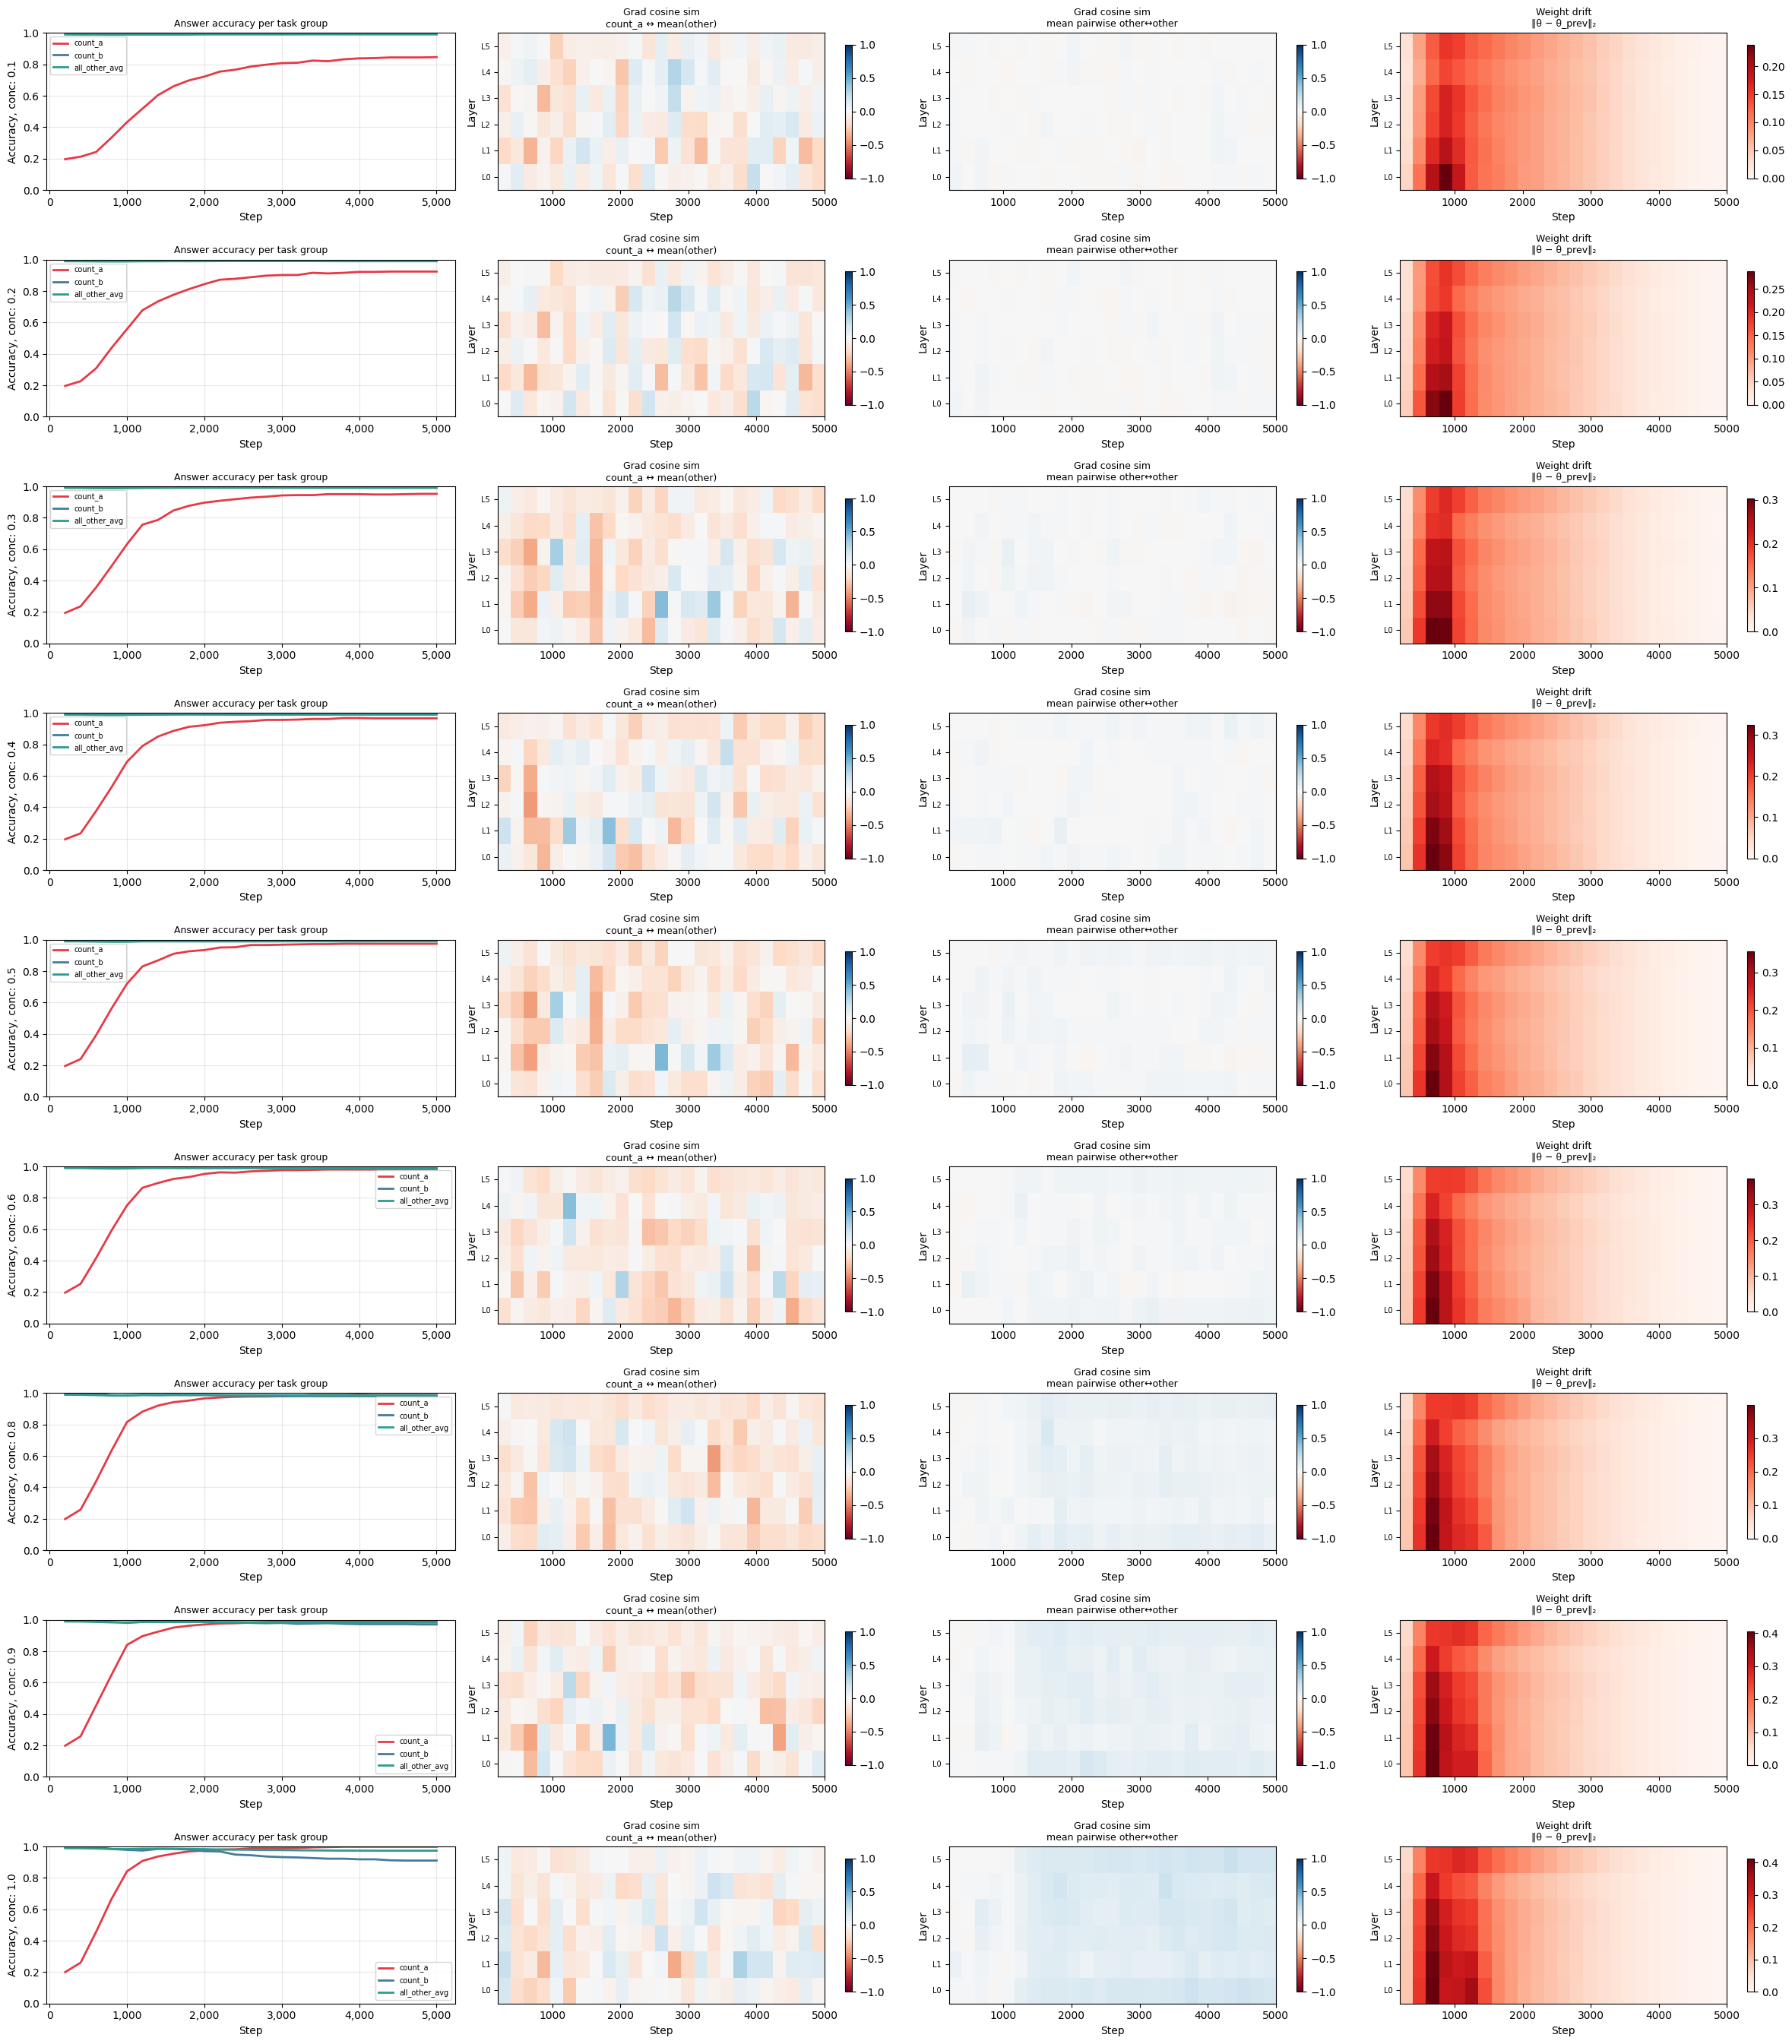

In [84]:
CONCENTRATIONS = np.sort(list(all_histories.keys()))

fig, axes = plt.subplots(len(CONCENTRATIONS), 4, figsize=(24, 3 * len(CONCENTRATIONS)))
for n, concentration in enumerate(CONCENTRATIONS):

    history = all_histories[concentration]
    # ── Panel 1: accuracy over time ───────────────────────────────────────────────
    ax = axes[n, 0]
    acc_series = {
        "count_a"      : history["val"]["count_a"]["answer_acc"],
        "count_b"      : history["val"]["count_b"]["answer_acc"],
        "all_other_avg": history["val"]["all_other_avg"]["answer_acc"],
    }
    acc_colors = {
        "count_a"      : "#e63946",
        "count_b"      : "#457b9d",
        "all_other_avg": "#2a9d8f",
    }
    for split_name, vals in acc_series.items():
        ax.plot(steps, vals, color=acc_colors[split_name], lw=2, label=split_name)
    ax.set_title("Answer accuracy per task group", fontsize=9)
    ax.set_xlabel("Step")
    ax.set_ylabel(f"Accuracy, conc: {concentration}")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(True, alpha=0.3)

    # ── Panels 2-4: heatmaps ──────────────────────────────────────────────────────
    sv_o_arr = np.array(history["grad_cossim_special_vs_other"])
    o_o_arr  = np.array(history["grad_cossim_other_vs_other"])
    drift_arr = np.array(history["weight_drift"])
    data_panels = [
        (sv_o_arr.T,  f"Grad cosine sim\n{SPECIAL_TASK} ↔ mean(other)", "RdBu", (-1, 1)),
        (o_o_arr.T,   "Grad cosine sim\nmean pairwise other↔other",       "RdBu", (-1, 1)),
        (drift_arr.T, "Weight drift\n‖θ − θ_prev‖₂",                     "Reds", (0, None)),
    ]
    for ax, (data, title, cmap, (vmin, vmax)) in zip(axes[n, 1:], data_panels):
        kwargs = dict(aspect="auto", origin="lower", cmap=cmap)
        if vmin is not None: kwargs["vmin"] = vmin
        if vmax is not None: kwargs["vmax"] = vmax
        im = ax.imshow(data, **kwargs,
                    extent=[steps[0], steps[-1], -0.5, n_layers - 0.5])
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Step")
        ax.set_ylabel("Layer")
        ax.set_yticks(range(n_layers))
        ax.set_yticklabels(layer_labels, fontsize=7)
        plt.colorbar(im, ax=ax, shrink=0.85)

    # plt.suptitle(
    #     f"corr={CORRELATION:.2f}  conc={CONCENTRATION:.2f}",
    #     fontsize=11, y=1.02,
    # )
    plt.tight_layout()
plt.show()